# Group03 - SOMLAP - Track 3, Task 3
    ## Improvement, Complete Attention x Dropout Control, 5-Fold CV, and Significance Testing

    **Run on Kaggle GPU T4 x2 using Run All.** Every training call has a maximum of 60 epochs with early stopping.
    Exact duplicate feature vectors remain within one split/fold. The missing Plain-CNN-without-dropout control completes the 2x2 attention-by-dropout comparison. Improvement selection uses validation data only; the test set is evaluated once.

In [1]:
# ==========================================================
# CELL 1 — Imports
# ==========================================================

import os
import time
import random
import warnings
import json
import joblib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from IPython.display import display, Image
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense,
    GlobalAveragePooling2D, Input, Activation, Rescaling
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

from scipy.stats import binomtest, wilcoxon

TensorFlow: 2.20.0
NumPy: 2.0.2
Pandas: 2.3.3


In [2]:
# ==========================================================
# CELL 2 — Kaggle GPU and Reproducibility
# ==========================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError(
        "No GPU detected. Select GPU T4 x2 or GPU P100 in Kaggle Settings."
    )

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.OneDeviceStrategy("/GPU:0")

NUM_REPLICAS = strategy.num_replicas_in_sync
BATCH_SIZE = 32
PER_REPLICA_BATCH_SIZE = BATCH_SIZE // NUM_REPLICAS
EPOCHS = 60

print("Physical GPUs:", len(gpus))
print("Strategy:", type(strategy).__name__)
print("Replicas:", NUM_REPLICAS)
print("Global batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Physical GPUs: 2
Strategy: MirroredStrategy
Replicas: 2
Global batch size: 32
Maximum epochs: 60


I0000 00:00:1787909211.521225      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787909211.524402      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# ==========================================================
# CELL 3 — Load SOMLAP Dataset
# Auto-detects the CSV path under /kaggle/input/
# If running locally, set LOCAL_PATH below.
# ==========================================================
import glob, os

# ── Kaggle: search for the CSV automatically ──
candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
somlap_candidates = [p for p in candidates if "somlap" in p.lower() or "SOMLAP" in p]

if somlap_candidates:
    DATA_PATH = somlap_candidates[0]
    print(f"Found dataset at: {DATA_PATH}")
else:
    # Fallback: list all CSVs found so user can pick
    print("SOMLAP CSV not auto-detected. CSVs found under /kaggle/input/:")
    for p in candidates:
        print(f"  {p}")
    # ── Set this manually if auto-detect fails ──
    DATA_PATH = "/kaggle/input/SOMLAP DATASET.csv"
    print(f"\nUsing fallback path: {DATA_PATH}")
    print("If this is wrong, set DATA_PATH manually above.")

df = pd.read_csv(DATA_PATH)
TARGET = "class"
X_all = df.drop(columns=[TARGET])
y_all = df[TARGET]

print(f"\nDataset Loaded: {df.shape}")
print(f"Classes : {sorted(y_all.unique())}")
print(f"Benign  : {(y_all==0).sum():,}   Malware: {(y_all==1).sum():,}")

# Aliases used in Task 2
X = X_all
y = y_all

print(f"Feature matrix: {X.shape}")
display(df.head(3))

Found dataset at: /kaggle/input/datasets/ravikiranvarmap/somlap-data-set/SOMLAP DATASET.csv

Dataset Loaded: (51408, 109)
Classes : [np.int64(0), np.int64(1)]
Benign  : 31,600   Malware: 19,808
Feature matrix: (51408, 108)


,blp,Fp,Rn,Prhdr,Minpar,Maxpar,Ivalss,Ivalsp,doscksum,Iip,...,bss_viraddr,bss_datsize,bss_ptrrawdat,bss_char,bss_entro,bss_phyaddr.1,bss_virsize.1,bss_viraddr.1,bss_char.1,class
0,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
1,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0
2,144,3,0,4,0,65535,0,184,0,0,...,0,0,0,0,0.0,0,0,0,0,0


In [4]:
# ==========================================================
# CELL 4 — Feature / Target Split
# ==========================================================
TARGET = "class"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(f"Features: {X.shape[1]}  Samples: {len(X):,}")
print(f"Benign  : {(y==0).sum():,}  Malware: {(y==1).sum():,}")
print(f"Ratio   : {(y==0).sum()/(y==1).sum():.2f}:1")

Features: 108  Samples: 51,408
Benign  : 31,600  Malware: 19,808
Ratio   : 1.60:1


---
## Leakage-aware split

Exact duplicate SOMLAP feature vectors are treated as one group. Every occurrence
of an identical vector is assigned entirely to training, validation, or testing.
This prevents duplicate memorization across splits while retaining all samples.

The same seed and grouping algorithm are used in the final baseline notebook.

In [5]:
# ==========================================================
# CELL 5 — Duplicate-Group 70/15/15 Split
# ==========================================================

feature_group = pd.util.hash_pandas_object(X, index=False).astype("uint64")
group_table = pd.DataFrame({"group": feature_group, "class": y})

group_label_counts = group_table.groupby("group")["class"].nunique()
if int((group_label_counts > 1).sum()) != 0:
    raise ValueError("Identical feature vectors with conflicting labels were found.")

unique_groups = group_table.drop_duplicates("group")
train_groups, temp_groups = train_test_split(
    unique_groups, test_size=0.30, random_state=SEED,
    stratify=unique_groups["class"]
)
valid_groups, test_groups = train_test_split(
    temp_groups, test_size=0.50, random_state=SEED,
    stratify=temp_groups["class"]
)

train_group_ids = set(train_groups["group"])
valid_group_ids = set(valid_groups["group"])
test_group_ids = set(test_groups["group"])

train_mask = feature_group.isin(train_group_ids)
valid_mask = feature_group.isin(valid_group_ids)
test_mask = feature_group.isin(test_group_ids)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_valid, y_valid = X.loc[valid_mask].copy(), y.loc[valid_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

assert not (train_group_ids & valid_group_ids)
assert not (train_group_ids & test_group_ids)
assert not (valid_group_ids & test_group_ids)
assert len(X_train) + len(X_valid) + len(X_test) == len(X)

split_df = pd.DataFrame({
    "Split": ["Training", "Validation", "Testing"],
    "Samples": [len(X_train), len(X_valid), len(X_test)],
    "Unique groups": [len(train_group_ids), len(valid_group_ids), len(test_group_ids)],
    "Benign": [(y_train == 0).sum(), (y_valid == 0).sum(), (y_test == 0).sum()],
    "Malware": [(y_train == 1).sum(), (y_valid == 1).sum(), (y_test == 1).sum()]
})

print("Exact duplicate rows grouped before splitting:", len(X) - feature_group.nunique())
print("Feature-group overlap across splits: 0")
display(split_df)

Exact duplicate rows grouped before splitting: 14367
Feature-group overlap across splits: 0


,Split,Samples,Unique groups,Benign,Malware
0,Training,36027,25928,22108,13919
1,Validation,7651,5556,4739,2912
2,Testing,7730,5557,4753,2977


In [6]:
# ==========================================================
# CELL 6 — Training-Only Scaling with Safe Clipping
# ==========================================================

scaler = StandardScaler()
X_tr_std = scaler.fit_transform(X_train)
X_va_std = scaler.transform(X_valid)
X_te_std = scaler.transform(X_test)

px_scaler = MinMaxScaler(feature_range=(0, 255))
X_tr_px = px_scaler.fit_transform(X_tr_std)
X_va_px = px_scaler.transform(X_va_std)
X_te_px = px_scaler.transform(X_te_std)

X_tr_px = np.clip(X_tr_px, 0, 255).astype(np.uint8)
X_va_px = np.clip(X_va_px, 0, 255).astype(np.uint8)
X_te_px = np.clip(X_te_px, 0, 255).astype(np.uint8)

print("Scaler fitted only on training data")
print("Train range:", X_tr_px.min(), "to", X_tr_px.max())
print("Validation range:", X_va_px.min(), "to", X_va_px.max())
print("Test range:", X_te_px.min(), "to", X_te_px.max())

Scaler fitted only on training data
Train range: 0 to 255
Validation range: 0 to 255
Test range: 0 to 255


Train: (36027, 12, 9)  Valid: (7651, 12, 9)  Test: (7730, 12, 9)


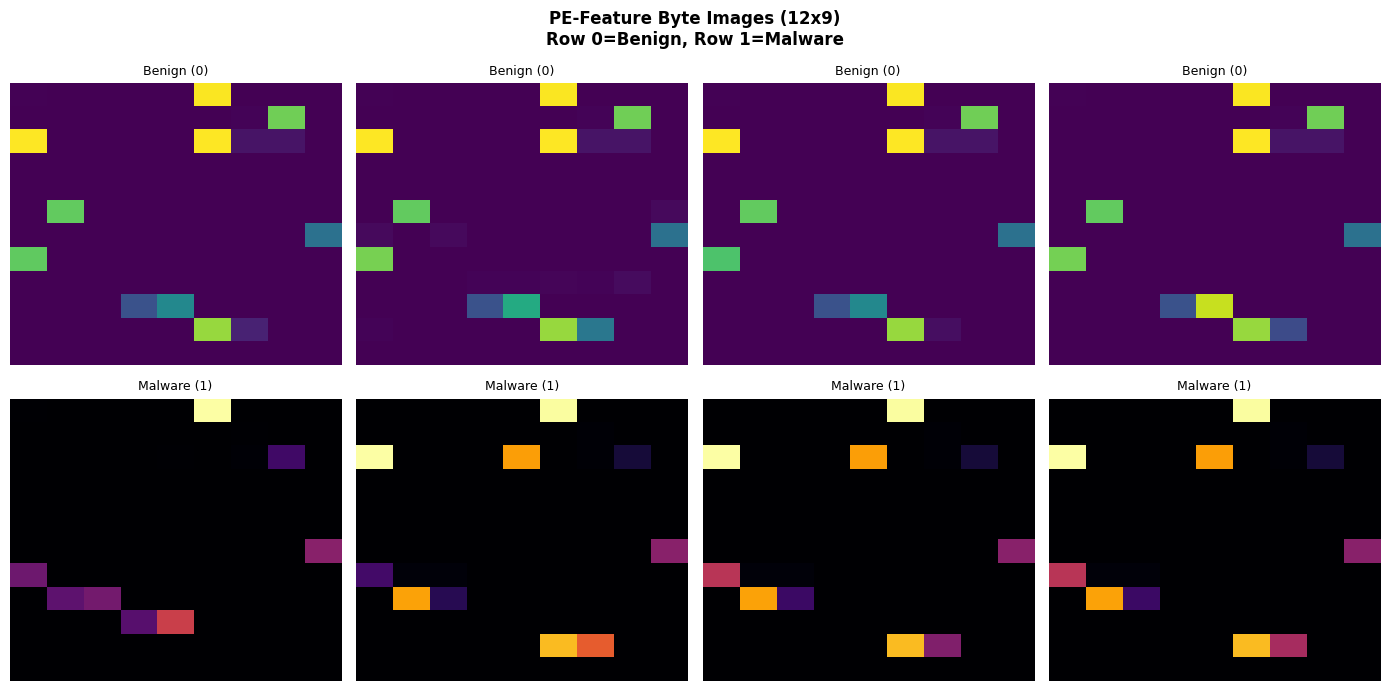

Reading: Benign and malware samples show distinct pixel patterns,
especially in TEXT-section rows (entropy, size fields).


In [7]:
# ==========================================================
# CELL 7 — Reshape to 12x9 Byte Images (108 = 12*9)
# ==========================================================
IMG_H, IMG_W = 12, 9
X_tr_img = X_tr_px.reshape(-1, IMG_H, IMG_W)
X_va_img = X_va_px.reshape(-1, IMG_H, IMG_W)
X_te_img = X_te_px.reshape(-1, IMG_H, IMG_W)

print(f"Train: {X_tr_img.shape}  Valid: {X_va_img.shape}  Test: {X_te_img.shape}")

# Visualise samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("PE-Feature Byte Images (12x9)\nRow 0=Benign, Row 1=Malware",
             fontsize=12, fontweight='bold')
bg = np.where(y_train.values == 0)[0][:4]
ml = np.where(y_train.values == 1)[0][:4]
for i, idx in enumerate(bg):
    axes[0,i].imshow(X_tr_img[idx], cmap="viridis", aspect="auto")
    axes[0,i].set_title("Benign (0)", fontsize=9); axes[0,i].axis("off")
for i, idx in enumerate(ml):
    axes[1,i].imshow(X_tr_img[idx], cmap="inferno", aspect="auto")
    axes[1,i].set_title("Malware (1)", fontsize=9); axes[1,i].axis("off")
plt.tight_layout()
plt.savefig("byte_image_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Reading: Benign and malware samples show distinct pixel patterns,")
print("especially in TEXT-section rows (entropy, size fields).")

In [8]:
# CELL 8 - Dataset factory with semantically safe augmentation
IMG_SIZE = 96
AUTOTUNE = tf.data.AUTOTUNE
AUGMENT_NOISE_STD = 1.5

def preprocess_image(image, label, augment=False):
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, -1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if augment:
        image += tf.random.normal(tf.shape(image), stddev=AUGMENT_NOISE_STD)
        image = tf.clip_by_value(image, 0.0, 255.0)
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)

def make_ds(images, labels, training=False, augment=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((images, np.asarray(labels)))
    if training:
        ds = ds.shuffle(min(10000, len(images)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: preprocess_image(x, y, augment and training),
                num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_ds(X_tr_img, y_train, training=True, augment=True)
valid_ds = make_ds(X_va_img, y_valid)
test_ds = make_ds(X_te_img, y_test)

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print("Datasets ready; global batch:", BATCH_SIZE, "class weights:", class_weights)

Datasets ready; global batch: 32 class weights: {0: 0.8147955491224896, 1: 1.294166247575257}


## Configurable attention model and fair ablation

In [9]:
# CELL 9 - Serializable channel and spatial attention
@tf.keras.utils.register_keras_serializable(package="Group03")
class ChannelAttention(layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs); self.reduction_ratio = reduction_ratio
    def build(self, input_shape):
        channels = int(input_shape[-1]); hidden = max(1, channels // self.reduction_ratio)
        self.fc1 = layers.Dense(hidden, activation="relu", use_bias=False)
        self.fc2 = layers.Dense(channels, use_bias=False)
        super().build(input_shape)
    def attention_weights(self, x):
        avg = tf.reduce_mean(x, axis=[1, 2]); maximum = tf.reduce_max(x, axis=[1, 2])
        w = tf.sigmoid(self.fc2(self.fc1(avg)) + self.fc2(self.fc1(maximum)))
        return tf.reshape(w, [-1, 1, 1, tf.shape(x)[-1]])
    def call(self, x): return x * self.attention_weights(x)
    def get_config(self):
        cfg = super().get_config(); cfg.update({"reduction_ratio": self.reduction_ratio}); return cfg

@tf.keras.utils.register_keras_serializable(package="Group03")
class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs); self.kernel_size = kernel_size
        self.conv = layers.Conv2D(1, kernel_size, padding="same", use_bias=False)
    def attention_mask(self, x):
        avg = tf.reduce_mean(x, -1, keepdims=True); maximum = tf.reduce_max(x, -1, keepdims=True)
        return tf.sigmoid(self.conv(tf.concat([avg, maximum], axis=-1)))
    def call(self, x): return x * self.attention_mask(x)
    def get_config(self):
        cfg = super().get_config(); cfg.update({"kernel_size": self.kernel_size}); return cfg

def apply_attention(x, kind, name):
    if kind in ("channel", "cbam"): x = ChannelAttention(16, name=f"{name}_ch")(x)
    if kind in ("spatial", "cbam"): x = SpatialAttention(7, name=f"{name}_sp")(x)
    return x

In [10]:
# CELL 10 - Configurable CNN factory for fair ablations
BASE_CONFIG = {
    "attention": "cbam", "blocks": 4, "batch_norm": True,
    "dropout": True, "conv_dropout": 0.30, "dense_dropout": 0.50,
    "augment": True, "learning_rate": 1e-3, "schedule": "plateau"
}

def build_model(config, name="Group03_Task3_Model"):
    cfg = {**BASE_CONFIG, **config}
    filters = [32, 64, 128, 256][:int(cfg["blocks"])]
    inputs = Input((IMG_SIZE, IMG_SIZE, 3), name="input")
    x = layers.Rescaling(1/255.0, name="rescale")(inputs)
    for i, f in enumerate(filters, start=1):
        x = Conv2D(f, 3, padding="same", use_bias=not cfg["batch_norm"], name=f"conv{i}")(x)
        if cfg["batch_norm"]: x = BatchNormalization(name=f"bn{i}")(x)
        x = Activation("relu", name=f"relu{i}")(x)
        if cfg["dropout"] and i in (2, 3):
            x = Dropout(cfg["conv_dropout"], name=f"drop{i}")(x)
        if i < len(filters):
            x = apply_attention(x, cfg["attention"], f"attn{i}")
            x = MaxPooling2D(2, name=f"pool{i}")(x)
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dense(256, use_bias=not cfg["batch_norm"], name="dense1")(x)
    if cfg["batch_norm"]: x = BatchNormalization(name="bn_dense1")(x)
    x = Activation("relu", name="relu_dense1")(x)
    if cfg["dropout"]: x = Dropout(cfg["dense_dropout"], name="drop_dense1")(x)
    x = Dense(128, use_bias=not cfg["batch_norm"], name="dense2")(x)
    if cfg["batch_norm"]: x = BatchNormalization(name="bn_dense2")(x)
    x = Activation("relu", name="relu_dense2")(x)
    if cfg["dropout"]: x = Dropout(cfg["dense_dropout"] * 0.8, name="drop_dense2")(x)
    outputs = Dense(1, activation="sigmoid", name="output")(x)
    model = Model(inputs, outputs, name=name)
    if cfg["schedule"] == "cosine":
        lr = tf.keras.optimizers.schedules.CosineDecay(cfg["learning_rate"], decay_steps=1200, alpha=0.05)
    else: lr = cfg["learning_rate"]
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")])
    return model

def callbacks_for(config, slug):
    callbacks = [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0),
                 ModelCheckpoint(f"{slug}_best.keras", monitor="val_loss", save_best_only=True, verbose=0)]
    if config.get("schedule", "plateau") == "plateau":
        callbacks.insert(1, ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                              min_lr=1e-7, verbose=0))
    return callbacks

In [11]:
# CELL 11 - Metric helper
def score_predictions(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int); y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "y_pred": y_pred, "y_prob": y_prob,
    }

def train_config(config, slug, train_images=X_tr_img, train_labels=y_train,
                 val_images=X_va_img, val_labels=y_valid, weights=class_weights, verbose=0):
    tf.keras.backend.clear_session(); tf.random.set_seed(SEED)
    tr = make_ds(train_images, train_labels, training=True, augment=config.get("augment", True))
    va = make_ds(val_images, val_labels)
    with strategy.scope(): model = build_model(config, slug)
    start = time.time()
    hist = model.fit(tr, validation_data=va, epochs=EPOCHS, class_weight=weights,
                     callbacks=callbacks_for(config, slug), verbose=verbose)
    elapsed = time.time() - start
    prob = model.predict(va, verbose=0).ravel()
    result = score_predictions(val_labels, prob)
    result.update({"Epochs": len(hist.history["loss"]), "Training Time (sec)": elapsed,
                   "Parameters": model.count_params()})
    return model, hist, result

In [12]:
# CELL 12 - Required ablation and improvement experiments (validation selection only)
EXPERIMENTS = [
    ("A Plain CNN", {"attention": "none"}),
    ("B Channel only", {"attention": "channel"}),
    ("C Spatial only", {"attention": "spatial"}),
    ("D Full CBAM", {"attention": "cbam"}),
    ("E CBAM no dropout", {"attention": "cbam", "dropout": False}),
    ("F CBAM no batch norm", {"attention": "cbam", "batch_norm": False}),
    ("G CBAM 3 blocks", {"attention": "cbam", "blocks": 3}),
    ("H CBAM augmentation off", {"attention": "cbam", "augment": False}),
    ("I CBAM cosine LR", {"attention": "cbam", "schedule": "cosine", "learning_rate": 5e-4}),
    # Missing factorial control: identical to E except that attention is disabled.
    ("J Plain CNN no dropout", {"attention": "none", "dropout": False}),
]

ablation_rows, ablation_configs = [], {}
for label, changes in EXPERIMENTS:
    config = {**BASE_CONFIG, **changes}; ablation_configs[label] = config
    print("Training", label)
    model, history, result = train_config(config, "abl_" + label[0], verbose=0)
    ablation_rows.append({"Experiment": label, **{k: v for k, v in result.items()
                          if k not in ("y_pred", "y_prob")}})
    print(f"  val Macro-F1={result['Macro F1']:.4f}, recall={result['Recall']:.4f}, epochs={result['Epochs']}")
    del model, history

ablation_df = pd.DataFrame(ablation_rows).sort_values("Macro F1", ascending=False)
display(ablation_df.round(5))

# Complete 2x2 factorial comparison: attention on/off x dropout on/off.
factorial_spec = [
    ("A Plain CNN", "No", "Yes"),
    ("J Plain CNN no dropout", "No", "No"),
    ("D Full CBAM", "Yes", "Yes"),
    ("E CBAM no dropout", "Yes", "No"),
]
factorial_lookup = ablation_df.set_index("Experiment")
factorial_rows = []
for label, attention_used, dropout_used in factorial_spec:
    row = factorial_lookup.loc[label]
    factorial_rows.append({
        "Model": label, "Attention": attention_used, "Dropout": dropout_used,
        "Accuracy": row["Accuracy"], "Macro F1": row["Macro F1"],
        "ROC AUC": row["ROC AUC"], "PR AUC": row["PR AUC"]
    })
factorial_df = pd.DataFrame(factorial_rows)
print("Complete attention x dropout control on validation data")
display(factorial_df.round(6))
fscore = factorial_df.set_index("Model")["Macro F1"]
print(f"Attention effect with dropout ON : {fscore['D Full CBAM'] - fscore['A Plain CNN']:+.6f}")
print(f"Attention effect with dropout OFF: {fscore['E CBAM no dropout'] - fscore['J Plain CNN no dropout']:+.6f}")
print(f"Dropout effect without attention : {fscore['A Plain CNN'] - fscore['J Plain CNN no dropout']:+.6f}")
print(f"Dropout effect with CBAM          : {fscore['D Full CBAM'] - fscore['E CBAM no dropout']:+.6f}")

# Track 3 requires an attention model, so select the best attention configuration
# using validation Macro-F1. The overall winner is also reported honestly.
attention_labels = [label for label, cfg in ablation_configs.items()
                    if cfg.get("attention", "none") != "none"]
attention_results = ablation_df[ablation_df["Experiment"].isin(attention_labels)]
best_label = attention_results.iloc[0]["Experiment"]
best_config = ablation_configs[best_label]
overall_best_label = ablation_df.iloc[0]["Experiment"]
print("Selected attention model from validation data:", best_label, best_config)
print("Overall validation winner (attention or plain):", overall_best_label)

Training A Plain CNN
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

E0000 00:00:1787909221.636212      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/abl_A_1/drop2_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  val Macro-F1=0.9542, recall=0.9303, epochs=27
Training B Channel only
INFO:tensorflow:Collective all_reduce tensors: 26 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1787910246.754994      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/abl_B_1/drop2_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  val Macro-F1=0.9467, recall=0.9581, epochs=21
Training C Spatial only
INFO:tensorflow:Collective all_reduce tensors: 23 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


...

  val Macro-F1=0.9093, recall=0.7950, epochs=10
Training J Plain CNN no dropout
INFO:tensorflow:Collective all_reduce tensors: 20 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
  val Macro-F1=0.9600, recall=0.9289, epochs=17


,Experiment,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1,ROC AUC,PR AUC,Epochs,Training Time (sec),Parameters
4,E CBAM no dropout,0.97294,0.95340,0.97665,0.96489,0.97144,0.97301,0.99561,0.98919,19,936.60074,492807
9,J Plain CNN no dropout,0.96262,0.97162,0.92891,0.94979,0.96001,0.96245,0.99313,0.97374,17,621.44699,489825
6,G CBAM 3 blocks,0.95883,0.96525,0.92514,0.94477,0.95597,0.95865,0.99362,0.98740,42,1863.94557,161957
0,A Plain CNN,0.95700,0.95556,0.93029,0.94275,0.95416,0.95688,0.99205,0.98096,27,1018.60889,489825
5,F CBAM no batch norm,0.95556,0.93771,0.94609,0.94188,0.95295,0.95560,0.99489,0.99185,16,652.92229,490215
2,C Spatial only,0.95439,0.94729,0.93201,0.93959,0.95147,0.95431,0.99171,0.98563,9,393.27211,490119
1,B Channel only,0.94929,0.91296,0.95810,0.93499,0.94671,0.94951,0.99145,0.98148,21,937.30063,492513
3,D Full CBAM,0.93935,0.93997,0.89801,0.91851,0.93511,0.93907,0.98568,0.96778,10,535.55972,492807
8,I CBAM cosine LR,0.91818,0.98763,0.79499,0.88090,0.90929,0.91607,0.99181,0.98496,10,508.53953,492807
7,H CBAM augmentation off,0.64345,0.93396,0.06799,0.12676,0.45138,0.52889,0.96367,0.91703,10,474.33312,492807


Complete attention x dropout control on validation data


,Model,Attention,Dropout,Accuracy,Macro F1,ROC AUC,PR AUC
0,A Plain CNN,No,Yes,0.956999,0.954160,0.992050,0.980960
1,J Plain CNN no dropout,No,No,0.962619,0.960008,0.993132,0.973739
2,D Full CBAM,Yes,Yes,0.939354,0.935109,0.985678,0.967781
3,E CBAM no dropout,Yes,No,0.972945,0.971440,0.995608,0.989185


Attention effect with dropout ON : -0.019051
Attention effect with dropout OFF: +0.011432
Dropout effect without attention : -0.005848
Dropout effect with CBAM          : -0.036331
Selected attention model from validation data: E CBAM no dropout {'attention': 'cbam', 'blocks': 4, 'batch_norm': True, 'dropout': False, 'conv_dropout': 0.3, 'dense_dropout': 0.5, 'augment': True, 'learning_rate': 0.001, 'schedule': 'plateau'}
Overall validation winner (attention or plain): E CBAM no dropout


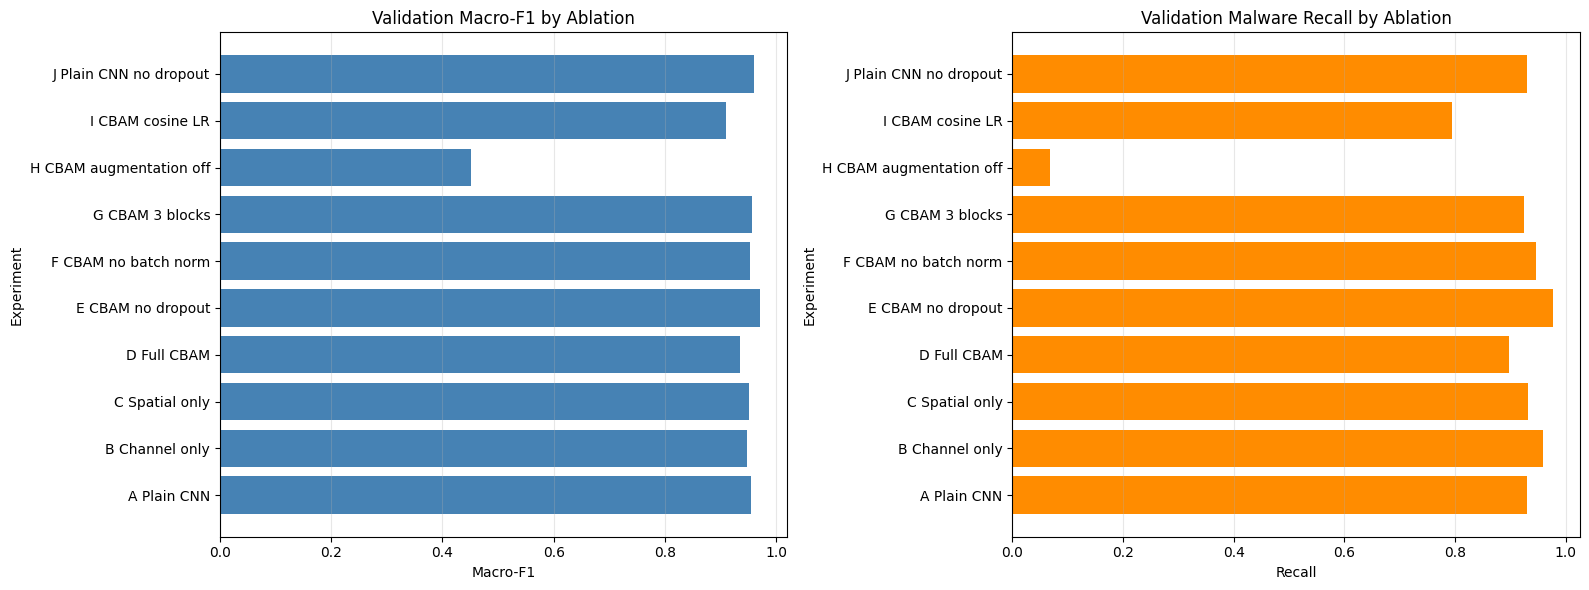

Reading: validation Macro-F1 selects the final configuration without using the test set; recall shows the security trade-off.


In [13]:
# CELL 13 - Ablation comparison figure
ordered = pd.DataFrame(ablation_rows)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(ordered["Experiment"], ordered["Macro F1"], color="steelblue")
axes[0].set_title("Validation Macro-F1 by Ablation"); axes[0].set_xlabel("Macro-F1"); axes[0].set_ylabel("Experiment")
axes[1].barh(ordered["Experiment"], ordered["Recall"], color="darkorange")
axes[1].set_title("Validation Malware Recall by Ablation"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Experiment")
for ax in axes: ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig("Group03_SOMLAP_task3_ablation.png", dpi=160, bbox_inches="tight"); plt.show()
print("Reading: validation Macro-F1 selects the final configuration without using the test set; recall shows the security trade-off.")

## Final test comparison and significance

In [14]:
# CELL 14 - Train selected final model and matched Plain CNN; test exactly once
# The comparison CNN is identical to the selected attention model except
# for attention=False. This controls dropout and all other settings.
plain_config = {**best_config, "attention": "none"}
assert plain_config["dropout"] == best_config["dropout"]
print("Matched comparison dropout setting:", plain_config["dropout"])
final_model, final_history, _ = train_config(best_config, "Group03_SOMLAP_task3_final", verbose=1)
plain_model, plain_history, _ = train_config(plain_config, "Group03_SOMLAP_task3_plain", verbose=1)

final_prob = final_model.predict(test_ds, verbose=0).ravel()
plain_prob = plain_model.predict(test_ds, verbose=0).ravel()
final_test = score_predictions(y_test, final_prob)
plain_test = score_predictions(y_test, plain_prob)

test_table = pd.DataFrame([
    {"Model": f"Matched Plain CNN (dropout={plain_config['dropout']})", **{k:v for k,v in plain_test.items() if k not in ("y_pred","y_prob")}},
    {"Model": f"Final: {best_label}", **{k:v for k,v in final_test.items() if k not in ("y_pred","y_prob")}},
])
display(test_table.round(6))
print("Matched Plain CNN classification report")
print(classification_report(y_test, plain_test["y_pred"], target_names=["Benign", "Malware"], digits=4))
print("Final attention model classification report")
print(classification_report(y_test, final_test["y_pred"], target_names=["Benign", "Malware"], digits=4))

Matched comparison dropout setting: False
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 29 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.9587 - auc: 0.9899 - loss: 0.1219 - precision: 0.9273 - recall: 0.9690 - val_accuracy: 0.3806 - val_auc: 0.5035 - val_loss: 6.9794 - val_precision: 0.3806 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 51s 45ms/step - accuracy: 0.9545 - auc: 0.9892 - loss: 0.1266 - precision: 0.9142 - recall: 0.9737 - val_accuracy: 0.9493 - val_auc: 0.9909 - val_loss: 0.1043 - val_precision: 0.9132 - val_recall: 0.9578 - learning_rate: 0.0010
Epoch 3/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 50s 44ms/step - accuracy: 0.9584 - auc: 0.9909 - loss: 0.1196 - precision: 0.9216 - recall: 0.9754 - val_accuracy: 0.9008 - val_auc: 0.9777 - val_loss: 0.3646 - val_precision: 0.9563 - val_recall: 0.7747 - learning_

,Model,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1,ROC AUC,PR AUC
0,Matched Plain CNN (dropout=False),0.978525,0.953241,0.992946,0.972688,0.977497,0.978602,0.997990,0.996780
1,Final: E CBAM no dropout,0.958732,0.979437,0.911992,0.944512,0.955831,0.958432,0.993836,0.988546


Matched Plain CNN classification report
              precision    recall  f1-score   support

      Benign     0.9955    0.9695    0.9823      4753
     Malware     0.9532    0.9929    0.9727      2977

    accuracy                         0.9785      7730
   macro avg     0.9744    0.9812    0.9775      7730
weighted avg     0.9792    0.9785    0.9786      7730

Final attention model classification report
              precision    recall  f1-score   support

      Benign     0.9472    0.9880    0.9672      4753
     Malware     0.9794    0.9120    0.9445      2977

    accuracy                         0.9587      7730
   macro avg     0.9633    0.9500    0.9558      7730
weighted avg     0.9596    0.9587    0.9584      7730



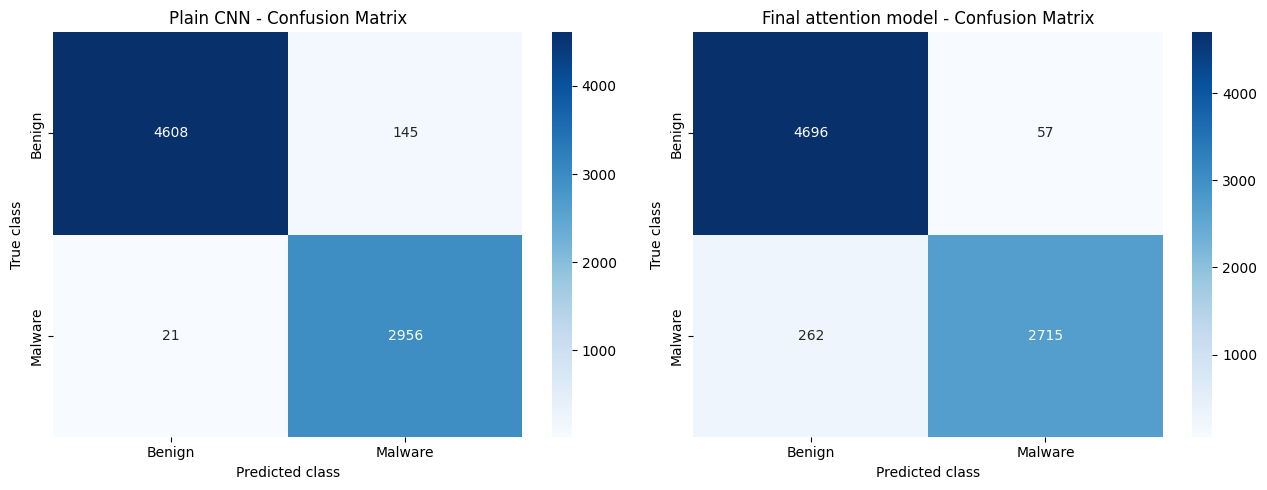

Reading: diagonal cells are correct; false-negative malware errors are the most security-critical.


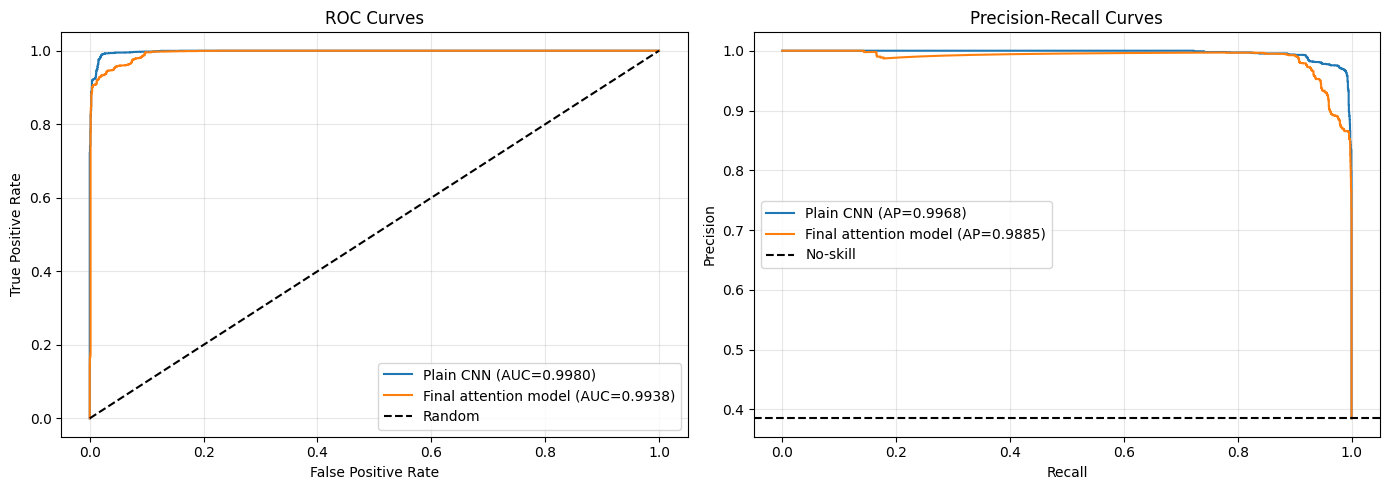

Reading: ROC measures separation; the PR curve exposes the precision-recall trade-off under imbalance.


In [15]:
# CELL 15 - Required confusion, ROC, and precision-recall figures
models_for_plot = {"Plain CNN": plain_test, "Final attention model": final_test}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, result) in zip(axes, models_for_plot.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malware"], yticklabels=["Benign", "Malware"])
    ax.set_title(name + " - Confusion Matrix"); ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
plt.tight_layout(); plt.savefig("task3_confusion_matrices.png", dpi=160, bbox_inches="tight"); plt.show()
print("Reading: diagonal cells are correct; false-negative malware errors are the most security-critical.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, result in models_for_plot.items():
    fpr, tpr, _ = roc_curve(y_test, result["y_prob"])
    pv, rv, _ = precision_recall_curve(y_test, result["y_prob"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={result['ROC AUC']:.4f})")
    axes[1].plot(rv, pv, label=f"{name} (AP={result['PR AUC']:.4f})")
axes[0].plot([0,1], [0,1], "k--", label="Random")
axes[0].set(title="ROC Curves", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].axhline(np.mean(y_test), color="k", ls="--", label="No-skill")
axes[1].set(title="Precision-Recall Curves", xlabel="Recall", ylabel="Precision")
for ax in axes: ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("task3_roc_pr.png", dpi=160, bbox_inches="tight"); plt.show()
print("Reading: ROC measures separation; the PR curve exposes the precision-recall trade-off under imbalance.")

In [16]:
# CELL 16 - Exact McNemar test on the shared held-out test set
truth = np.asarray(y_test).astype(int)
plain_correct = plain_test["y_pred"] == truth
final_correct = final_test["y_pred"] == truth
b = int(np.sum(final_correct & ~plain_correct))
c = int(np.sum(~final_correct & plain_correct))
mc_p = binomtest(min(b, c), n=b+c, p=0.5, alternative="two-sided").pvalue if b+c else 1.0
print("McNemar discordant counts: final-right/plain-wrong =", b,
      "; final-wrong/plain-right =", c)
print(f"Exact McNemar p-value = {mc_p:.6g}; alpha = 0.05")
print("Conclusion:", "significant difference" if mc_p < 0.05 else "no statistically significant difference")

McNemar discordant counts: final-right/plain-wrong = 122 ; final-wrong/plain-right = 275
Exact McNemar p-value = 1.11427e-14; alpha = 0.05
Conclusion: significant difference


## Paired leakage-safe 5-fold cross-validation

In [17]:
# CELL 17 - Leakage-safe paired 5-fold CV for Plain CNN and final model
dev_mask = train_mask | valid_mask
X_dev_raw = X.loc[dev_mask].reset_index(drop=True)
y_dev_raw = y.loc[dev_mask].reset_index(drop=True)
g_dev = feature_group.loc[dev_mask].reset_index(drop=True)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(X_dev_raw, y_dev_raw, groups=g_dev), start=1):
    print(f"Fold {fold}/5")
    fold_scaler = StandardScaler(); fold_px = MinMaxScaler((0,255))
    tr_std = fold_scaler.fit_transform(X_dev_raw.iloc[tr_idx]); va_std = fold_scaler.transform(X_dev_raw.iloc[va_idx])
    tr_px = np.clip(fold_px.fit_transform(tr_std),0,255).astype(np.uint8).reshape(-1,IMG_H,IMG_W)
    va_px = np.clip(fold_px.transform(va_std),0,255).astype(np.uint8).reshape(-1,IMG_H,IMG_W)
    ytr = y_dev_raw.iloc[tr_idx].to_numpy(); yva = y_dev_raw.iloc[va_idx].to_numpy()
    cw = compute_class_weight("balanced", classes=np.unique(ytr), y=ytr)
    fw = {int(c):float(w) for c,w in zip(np.unique(ytr),cw)}
    for model_name, cfg in [("Plain CNN", plain_config), ("Final attention", best_config)]:
        model, history, result = train_config(cfg, f"cv{fold}_{model_name.replace(' ','_')}",
                                              tr_px, ytr, va_px, yva, fw, verbose=0)
        cv_rows.append({"Fold":fold, "Model":model_name, **{k:v for k,v in result.items()
                       if k not in ("y_pred","y_prob")}})
        print(model_name, "Macro-F1", round(result["Macro F1"],4))
        del model, history

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(5))

Fold 1/5
INFO:tensorflow:Collective all_reduce tensors: 20 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
Plain CNN Macro-F1 0.9829
INFO:tensorflow:Collective all_reduce tensors: 29 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
Final attention Macro-F1 0.9738
Fold 2/5
INFO:tensorflow:Collective all_reduce tensors: 20 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
Plain CNN Macro-F1 0.9864
INFO:tensorflow:Collective all_reduce tensors: 29 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
Final attention Macro-F1 0.9848
Fold 3/5
INFO:tensorflow:Collective all_reduce tensors: 20 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
Plain CNN Macro-F1 0.9834
INFO:tensorflow:Collective

,Fold,Model,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1,ROC AUC,PR AUC,Epochs,Training Time (sec),Parameters
0,1,Plain CNN,0.98389,0.97364,0.98426,0.97892,0.98294,0.98391,0.99796,0.99601,26,945.45099,489825
1,1,Final attention,0.97515,0.95330,0.98274,0.96780,0.97378,0.97522,0.99803,0.99679,20,981.86497,492807
2,2,Plain CNN,0.98708,0.98204,0.98465,0.98334,0.98639,0.98708,0.99883,0.99765,39,1423.96381,489825
3,2,Final attention,0.98559,0.97829,0.98465,0.98146,0.98484,0.98560,0.99890,0.99804,39,1924.96661,492807
4,3,Plain CNN,0.98425,0.97484,0.98463,0.97971,0.98342,0.98427,0.99834,0.99704,34,1253.21448,489825
5,3,Final attention,0.98311,0.97008,0.98670,0.97832,0.98224,0.98314,0.99844,0.99669,30,1399.59164,492807
6,4,Plain CNN,0.98375,0.96986,0.98877,0.97923,0.98294,0.98378,0.99850,0.99735,33,1041.93518,489825
7,4,Final attention,0.98352,0.98129,0.97607,0.97867,0.98263,0.98352,0.99847,0.99746,49,2125.61517,492807
8,5,Plain CNN,0.97677,0.95888,0.98191,0.97026,0.97560,0.97682,0.99749,0.99600,33,1025.03851,489825
9,5,Final attention,0.98180,0.97656,0.97628,0.97642,0.98080,0.98180,0.99706,0.99507,25,1085.58335,492807


In [18]:
# CELL 18 - Mean +/- std and paired Wilcoxon across folds
metrics = ["Accuracy","Precision","Recall","F1","Macro F1","Weighted F1","ROC AUC","PR AUC"]
summary_rows = []
for model_name, group in cv_df.groupby("Model"):
    row = {"Model":model_name}
    for metric in metrics: row[metric] = f"{group[metric].mean():.4f} +/- {group[metric].std(ddof=1):.4f}"
    summary_rows.append(row)
cv_summary_df = pd.DataFrame(summary_rows)
display(cv_summary_df)

pivot = cv_df.pivot(index="Fold", columns="Model", values="Macro F1")
try:
    w_stat, w_p = wilcoxon(pivot["Final attention"], pivot["Plain CNN"], alternative="two-sided")
except ValueError:
    w_stat, w_p = 0.0, 1.0
print(f"Wilcoxon signed-rank across folds: W={w_stat:.4f}, p={w_p:.6g}, alpha=0.05")
print("Reading:", "fold-level Macro-F1 differs significantly." if w_p < .05 else
      "the five paired folds do not establish a significant Macro-F1 difference.")

,Model,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1,ROC AUC,PR AUC
0,Final attention,0.9818 +/- 0.0040,0.9719 +/- 0.0112,0.9813 +/- 0.0049,0.9765 +/- 0.0052,0.9809 +/- 0.0042,0.9819 +/- 0.0040,0.9982 +/- 0.0007,0.9968 +/- 0.0011
1,Plain CNN,0.9831 +/- 0.0038,0.9719 +/- 0.0085,0.9848 +/- 0.0025,0.9783 +/- 0.0048,0.9823 +/- 0.0040,0.9832 +/- 0.0038,0.9982 +/- 0.0005,0.9968 +/- 0.0008


Wilcoxon signed-rank across folds: W=4.0000, p=0.4375, alpha=0.05
Reading: the five paired folds do not establish a significant Macro-F1 difference.


## Save artifacts and summarize

In [19]:
# CELL 19 - Save models, predictions, preprocessing, and configuration
final_model.save("Group03_SOMLAP_task3_best.keras")
plain_model.save("Group03_SOMLAP_task3_plain.keras")
joblib.dump({"standard_scaler": scaler, "pixel_scaler": px_scaler,
             "feature_names": list(X.columns)}, "Group03_SOMLAP_task3_preprocessing.joblib")
with open("Group03_SOMLAP_task3_best_config.json", "w") as f: json.dump(best_config, f, indent=2)
with open("Group03_SOMLAP_label_map.json", "w") as f: json.dump({"0":"Benign","1":"Malware"}, f, indent=2)
np.savez_compressed("Group03_SOMLAP_task3_test_predictions.npz", y_true=np.asarray(y_test),
                    plain_prob=plain_prob, final_prob=final_prob)
ablation_df.to_csv("Group03_SOMLAP_task3_ablation_results.csv", index=False)
factorial_df.to_csv("Group03_SOMLAP_task3_attention_dropout_2x2.csv", index=False)
cv_df.to_csv("Group03_SOMLAP_task3_cv_results.csv", index=False)
print("Saved final/matched-plain models, preprocessing, configurations, paired predictions, and result tables.")

Saved final/matched-plain models, preprocessing, configurations, paired predictions, and result tables.


In [20]:
# CELL 20 - Final Task 3 comparison and honest reading
task2_rows = pd.DataFrame([
 {"Stage":"Task 2 best baseline", "Model":"Plain CNN", "Accuracy":0.950841, "Macro F1":0.948204, "ROC AUC":0.993128},
 {"Stage":"Task 2 first attention", "Model":"CNN+CBAM", "Accuracy":0.949159, "Macro F1":0.947318, "ROC AUC":0.995448},
 {"Stage":"Task 3 final", "Model":best_label, "Accuracy":final_test["Accuracy"], "Macro F1":final_test["Macro F1"], "ROC AUC":final_test["ROC AUC"]},
])
display(task2_rows.round(6))
matched_gain = final_test["Macro F1"] - plain_test["Macro F1"]
print(f"Matched held-out attention effect on Macro-F1: {matched_gain:+.6f}")
if matched_gain > 0:
    print("Honest attention conclusion: CBAM outperformed the dropout-matched Plain CNN on this held-out test.")
elif matched_gain < 0:
    print("Honest attention conclusion: CBAM did not outperform the dropout-matched Plain CNN on this held-out test.")
else:
    print("Honest attention conclusion: CBAM and the dropout-matched Plain CNN tied on held-out Macro-F1.")
print("Configuration selection used validation Macro-F1; the held-out test was used once after selection.")
print("Related-work numbers must be added from the group's verified Task 1 paper table; no paper result is invented here.")
print("SOMLAP is a synthetic feature grid, so spatial explanations are approximate feature-location emphasis.")

,Stage,Model,Accuracy,Macro F1,ROC AUC
0,Task 2 best baseline,Plain CNN,0.950841,0.948204,0.993128
1,Task 2 first attention,CNN+CBAM,0.949159,0.947318,0.995448
2,Task 3 final,E CBAM no dropout,0.958732,0.955831,0.993836


Matched held-out attention effect on Macro-F1: -0.021666
Honest attention conclusion: CBAM did not outperform the dropout-matched Plain CNN on this held-out test.
Configuration selection used validation Macro-F1; the held-out test was used once after selection.
Related-work numbers must be added from the group's verified Task 1 paper table; no paper result is invented here.
SOMLAP is a synthetic feature grid, so spatial explanations are approximate feature-location emphasis.
